In [1]:
import sys
sys.path.append('/Users/mariana/Documents/projects/Huawei/survan')

from lambda_cox import LambdaSA
from utils import concordance_index, unroll_time, unroll, score
import yaml
import jax
import jax.numpy as jnp
import haiku as hk
import numpy as np
import matplotlib.pyplot as plt

In [2]:
config_path = '../configs/config_aids.yaml'
config = yaml.load(open(config_path, 'r'), Loader=yaml.FullLoader)

In [3]:
config['axis'] = 1

In [4]:
agent = LambdaSA(config, 42)

In [5]:
xs = agent.data['seqs']
ts = agent.data['ts']
cs = agent.data['cs']

n, H, _ = xs.shape
# xs = jnp.concatenate((xs, jnp.tile(jnp.eye(H), (n, 1, 1))), axis=-1)
# agent.integrated_brier_score(xs[:,0], ts, cs)

In [6]:
xs.shape

(467, 5, 5)

In [7]:
sc = agent.survival_curve(xs[:,0])

In [8]:
sc.shape

(467, 6)

In [9]:
# 5-fold cross-validation
rng = np.random.default_rng(seed=0)
n_folds = 5
zs = np.append(((n / n_folds) * np.arange(n_folds)).astype(int), n)
idx = rng.permutation(n)
idx = jnp.array(idx)

def get_fold(fold):
    z1 = zs[fold]
    z2 = zs[fold + 1]
    idx_train = jnp.concatenate((idx[:z1], idx[z2:]))
    idx_valid = idx[z1:z2]
    return (
        (seqs[idx_train], ts[idx_train], cs[idx_train]),
        (seqs[idx_valid], ts[idx_valid], cs[idx_valid]),
    )

In [10]:
model = LambdaSA(config, 42)

In [11]:
seqs = agent.data['seqs']
ts = agent.data['ts']
cs = agent.data['cs']

In [12]:
%%time

sizes = 20 * jnp.arange(1, 11)

res2_is = np.zeros((n_folds, len(sizes)))
res2_lm = np.zeros((n_folds, len(sizes)))
res2_td = np.zeros((n_folds, len(sizes)))

res3_is = np.zeros((n_folds, len(sizes)))
res3_lm = np.zeros((n_folds, len(sizes)))
res3_td = np.zeros((n_folds, len(sizes)))

for fold in range(n_folds):
    (seqs_t, ts_t, cs_t), (seqs_v, ts_v, cs_v) = get_fold(fold)
    for i, size in enumerate(sizes):
        print(".", end="")
        seqs_, ts_, cs_ = unroll(seqs_t[:size], ts_t[:size], cs_t[:size])
        
        # Initial state.
        model = LambdaSA(config, 42)
        model.train(seqs_t[:size], ts_t[:size], cs_t[:size])
        sc_v = model.survival_curve(seqs_v[:,0])
        res2_is[fold, i] = model.integrated_brier_score(sc_v, ts_v, cs_v, jnp.ones_like(ts_v))
        beta = model.state.params['cox_linear_model']['beta']
        scores = score(beta, seqs_v[:, 0])
        res3_is[fold, i] = concordance_index(scores, ts_v, cs_v)
        
        # Landmarking.
        model = LambdaSA(config, 42)
        model.lambda_ = 1.0
        model.train(seqs_, ts_, cs_)
        sc_v = model.survival_curve(seqs_v[:,0])  # Shouldn't we use seqs_ instead of seqs?
        res2_lm[fold, i] = model.integrated_brier_score(sc_v, ts_v, cs_v, jnp.ones_like(ts_v))
        beta = model.state.params['cox_linear_model']['beta']
        scores = score(beta, seqs_v[:, 0])
        res3_lm[fold, i] = concordance_index(scores, ts_v, cs_v)
        
        # Temporal difference.
        model = LambdaSA(config, 42)
        model.lambda_ = 0.0
        model.train(seqs_, ts_, cs_)
        sc_v = model.survival_curve(seqs_v[:,0])
        res2_td[fold, i] = model.integrated_brier_score(sc_v, ts_v, cs_v, jnp.ones_like(ts_v))
        beta = model.state.params['cox_linear_model']['beta']
        scores = score(beta, seqs_v[:, 0])
        res3_td[fold, i] = concordance_index(scores, ts_v, cs_v)
        
    print()

..........
..........
..........
..........
..........
CPU times: user 2min 13s, sys: 1.62 s, total: 2min 15s
Wall time: 2min 13s


Text(0.5, 0, 'Number of patients')

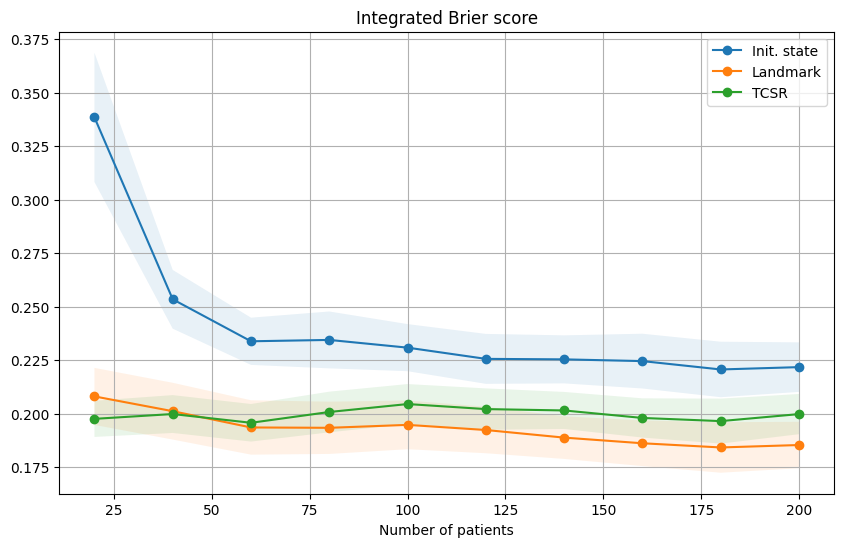

In [13]:
fig, ax = plt.subplots(figsize=(10, 6))

for res, label in ((res2_is, "Init. state"), (res2_lm, "Landmark"), (res2_td, "TCSR")):
    mean = res.mean(axis=0)
    std = res.std(axis=0) / np.sqrt(n_folds)
    ax.plot(sizes, mean, marker="o", label=label)
    ax.fill_between(sizes, mean - std, mean + std, alpha=0.1)

ax.legend()
ax.grid()
ax.set_title("Integrated Brier score")
ax.set_xlabel("Number of patients")

Text(0.5, 0, 'Number of patients')

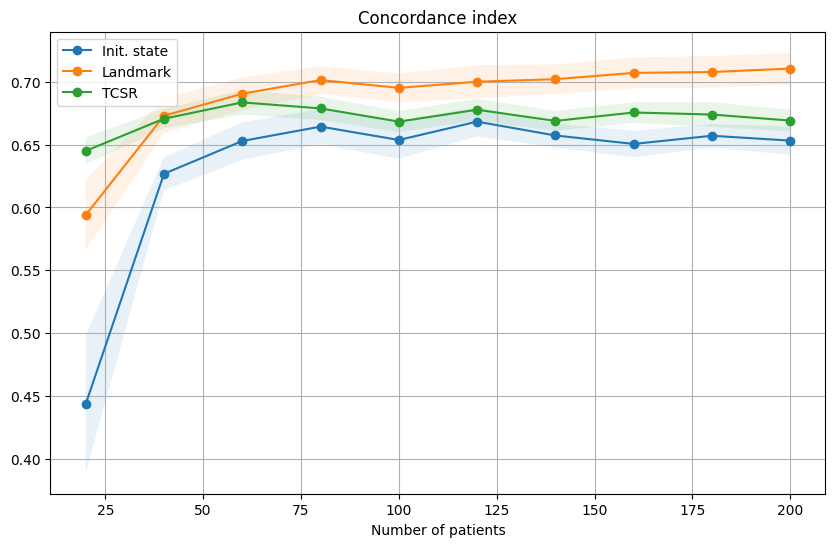

In [14]:
fig, ax = plt.subplots(figsize=(10, 6))

for res, label in ((res3_is, "Init. state"), (res3_lm, "Landmark"), (res3_td, "TCSR")):
    mean = res.mean(axis=0)
    std = res.std(axis=0) / np.sqrt(n_folds)
    ax.plot(sizes, mean, marker="o", label=label)
    ax.fill_between(sizes, mean - std, mean + std, alpha=0.1)

ax.legend()
ax.grid()
ax.set_title("Concordance index")
ax.set_xlabel("Number of patients")